# Low northern variance $\sigma_{16}$


In [1]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.mlab as mlab
import numpy as np
import healpy as hp
import polymv
import pylab as pl
import math
import sys
sys.path.insert(1, '../../scripts')
import CMBanom
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Parameters
load_stats_from_cluster = False
gen_maps_on_fly = False
ecliptic_coords = True
Nside_out = 16

if load_stats_from_cluster: Nsims = 100000
else:                       Nsims = 1000

In [3]:
# Directories
sims_dir  = "../../data/sims/"
stats_dir = "../../data/stats/"
real_dir  = "../../data/real/"
masks_dir = "../../data/masks/"

# Planck maps
names_Planck  = ["commander_nside_128", "nilc_nside_128", "sevem_nside_128", "smica_nside_128", "cleaned70GHz_v7_nside_128",     "cleaned94GHz_v7_nside_128", "cleaned100GHz_v7_nside_128", "cleaned143GHz_v7_nside_128"]
labels_Planck = [r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$", r"$70\, \mathrm{GHz}$", r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$"]
colors_Planck = ["tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [     "--",   "--",    "--",    "--",       "-",       "-",      "-",      "-"]
Nmaps = len(names_Planck)
index_Planck  = 0
index_Hayley  = 6

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]
mask_files = ["stdv_mask_1percent_cutoff_0.9_nside_16.fits", "com_mask_cutoff_0.9_nside_16.fits"]
mask_fn_south_ecl = "mask_south_ecl_nside_16.fits"
Nmasks = len(names_mask)

# Cls
cl_fn = "../../data/Cls/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}
prop = {'family': 'Helvetica', 'size': 20}

# Read maps & masks

In [5]:
# Read masks and save 0's as NaN's
masks_01 = CMBanom.read_masks(masks_dir, mask_files, Nside_out)

if ecliptic_coords:
    mask_for_north = hp.read_map(masks_dir+mask_fn_south_ecl)
    mask_for_south = np.where(hp.read_map(masks_dir+mask_fn_south_ecl)==1, 0, 1)
else:
    mask_for_north = np.append(np.ones(len_mask_16/2), np.zeros(len_mask_16/2))
    mask_for_north = np.append(np.zeros(len_mask_16/2), np.ones(len_mask_16/2))

#masks = np.where(np.array([mask*mask_for_north for mask in masks_01])==0, np.NaN, 1)
masks = np.where(np.array([mask*mask_for_south for mask in masks_01])==0, np.NaN, 1)
masks_south = np.where(np.array([mask*mask_for_south for mask in masks_01])==0, np.NaN, 1)

In [6]:
# Read in maps in muK
maps_Planck_hr = [hp.read_map(real_dir+"map_"+names_Planck[n]+".fits") for n in range(Nmaps)]
maps_Planck = np.array([CMBanom.downgrade_map(maps_Planck_hr[n], Nside_out) for n in range(Nmaps)])

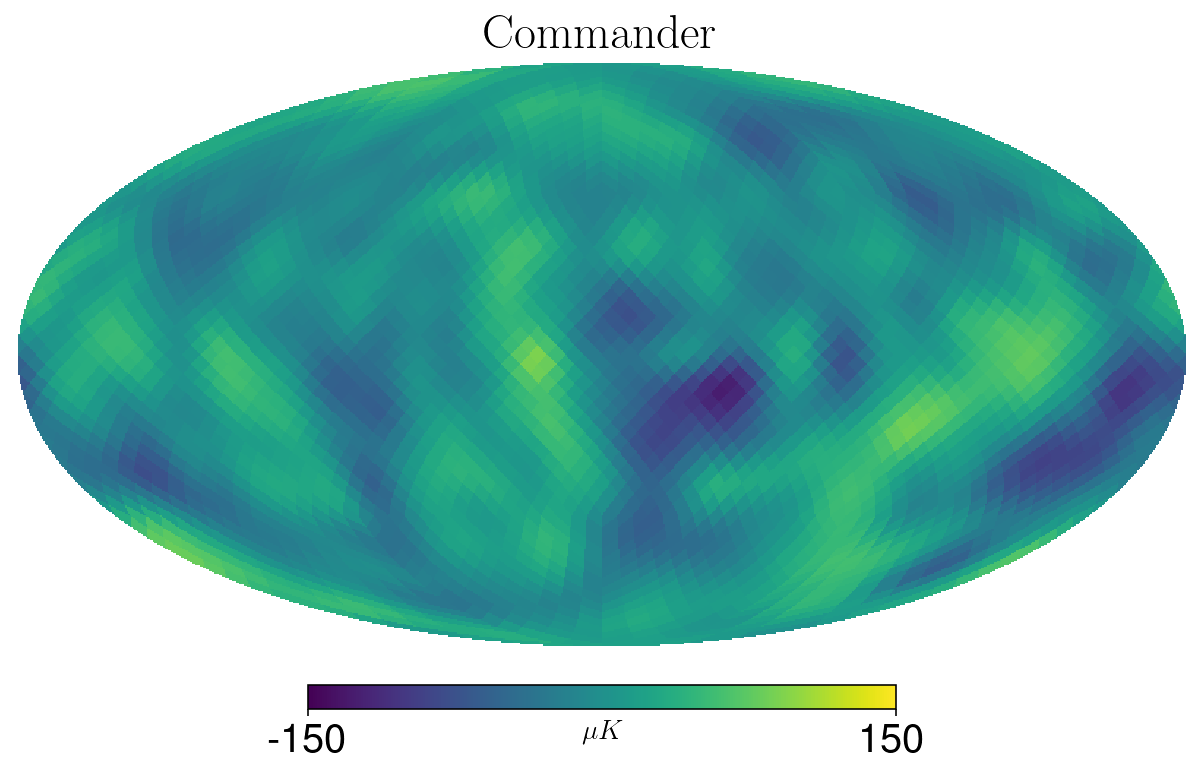

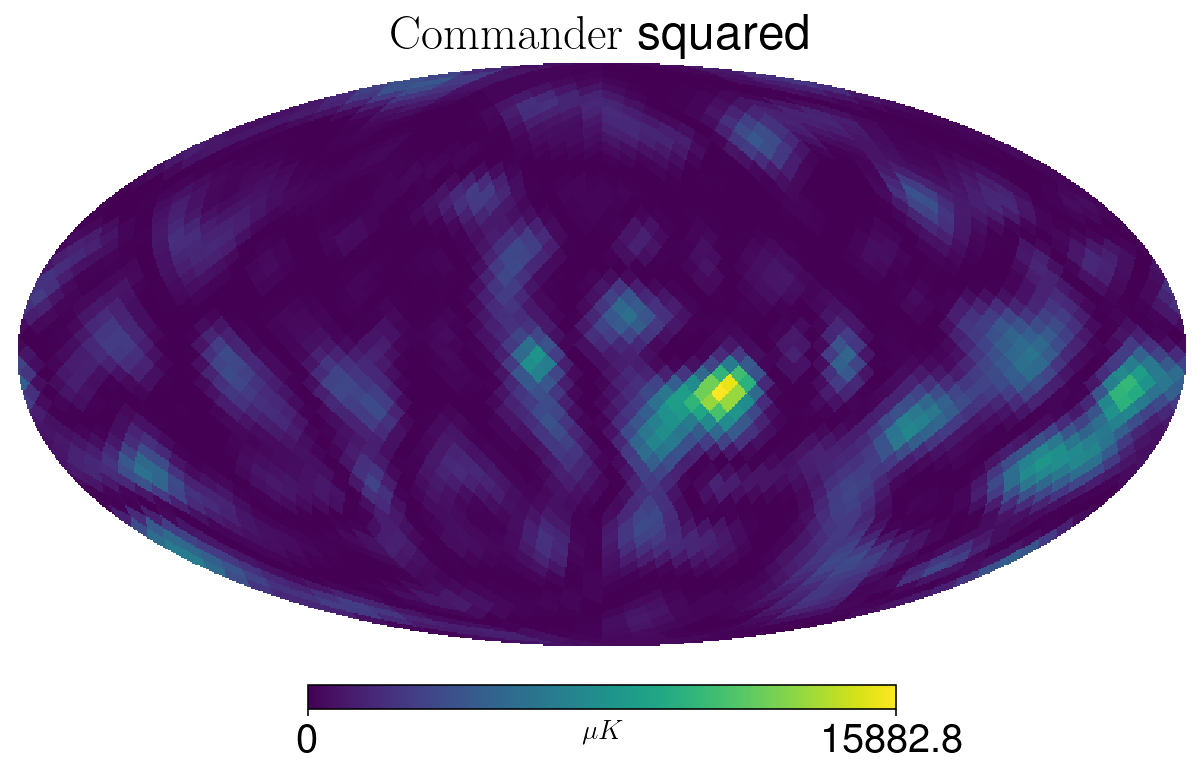

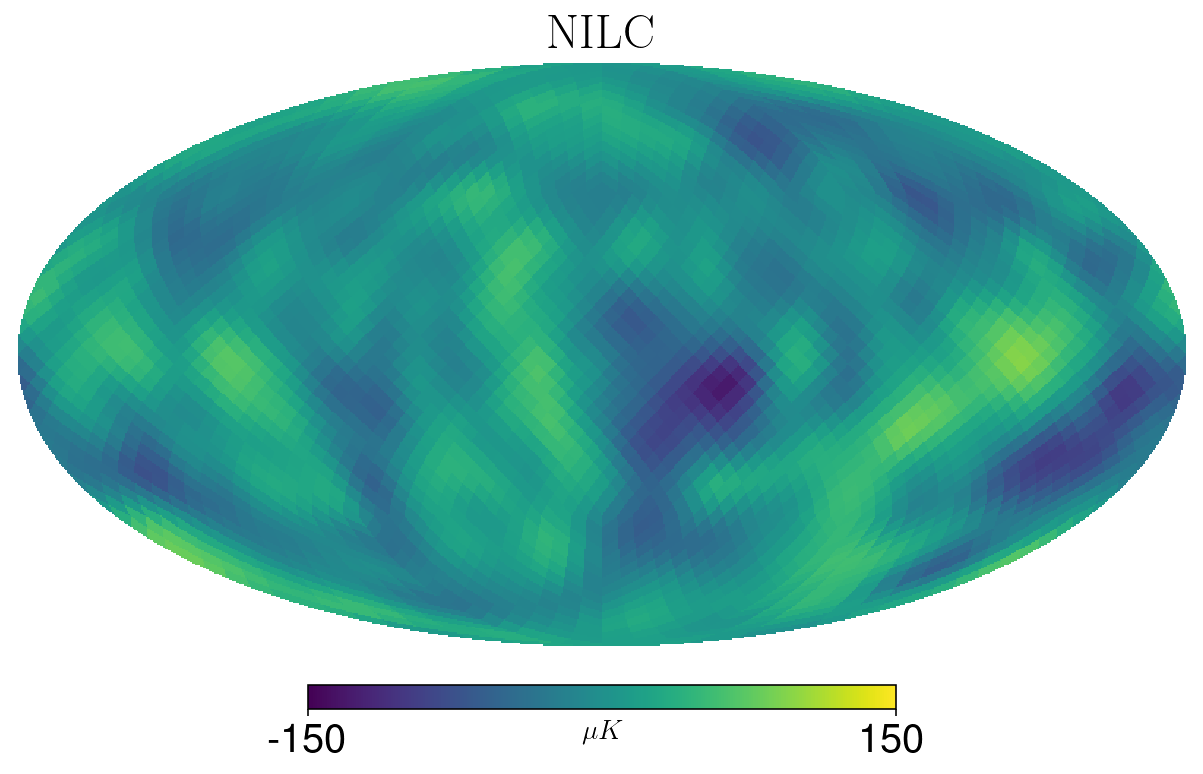

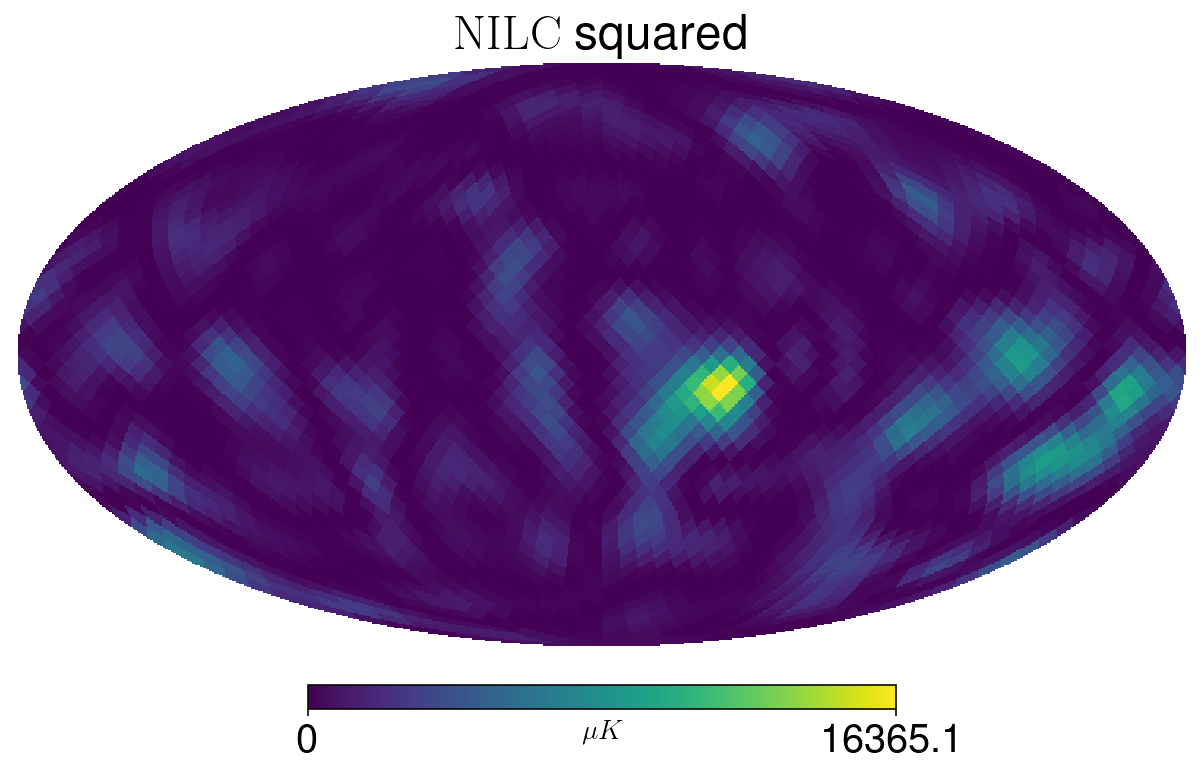

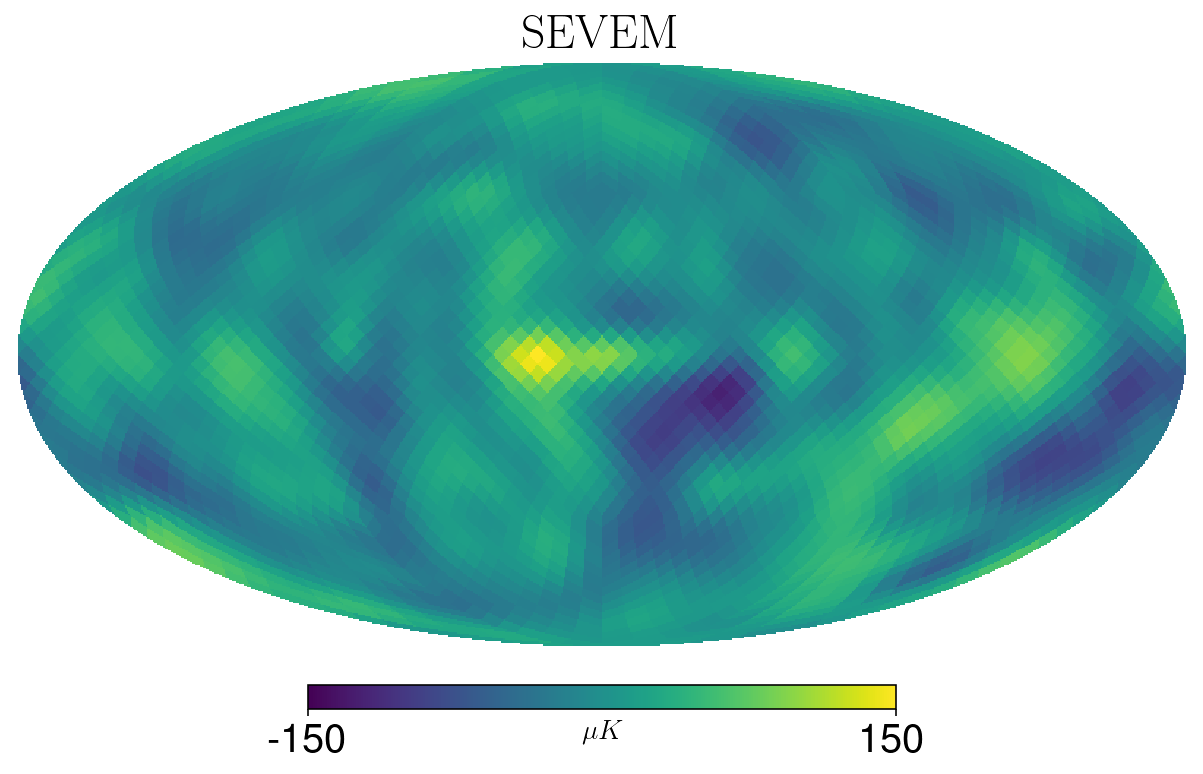

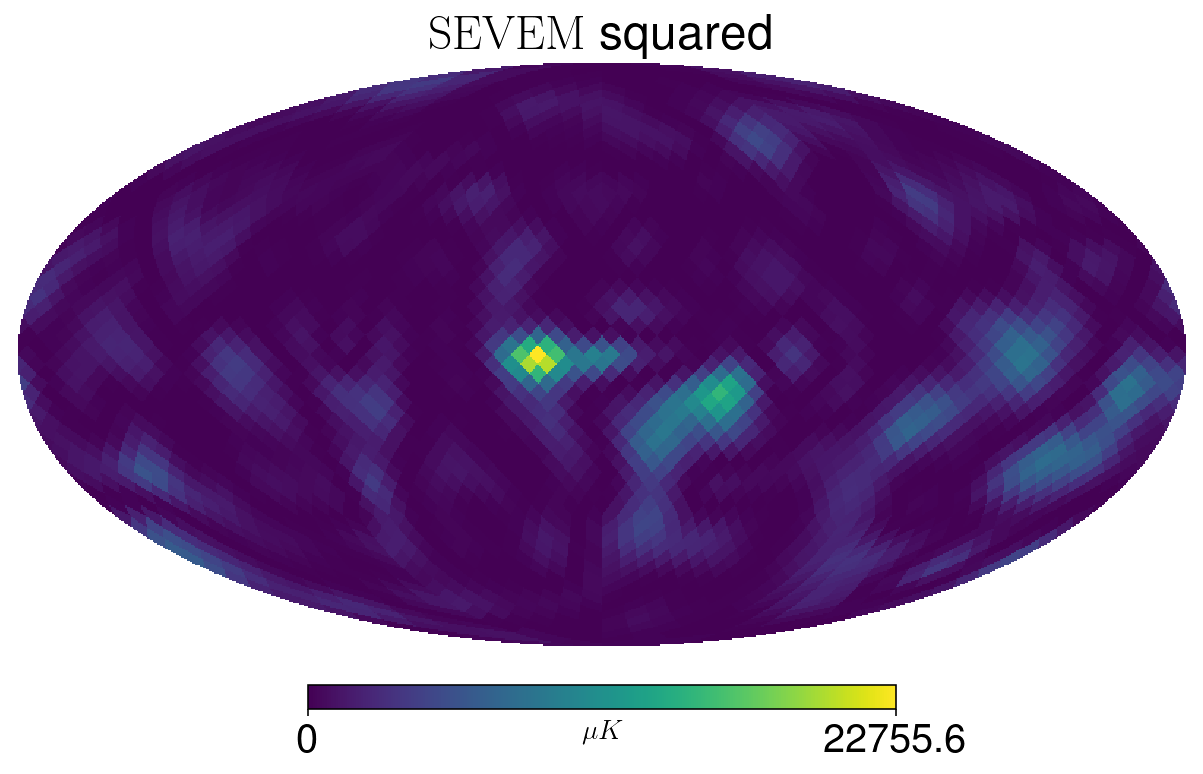

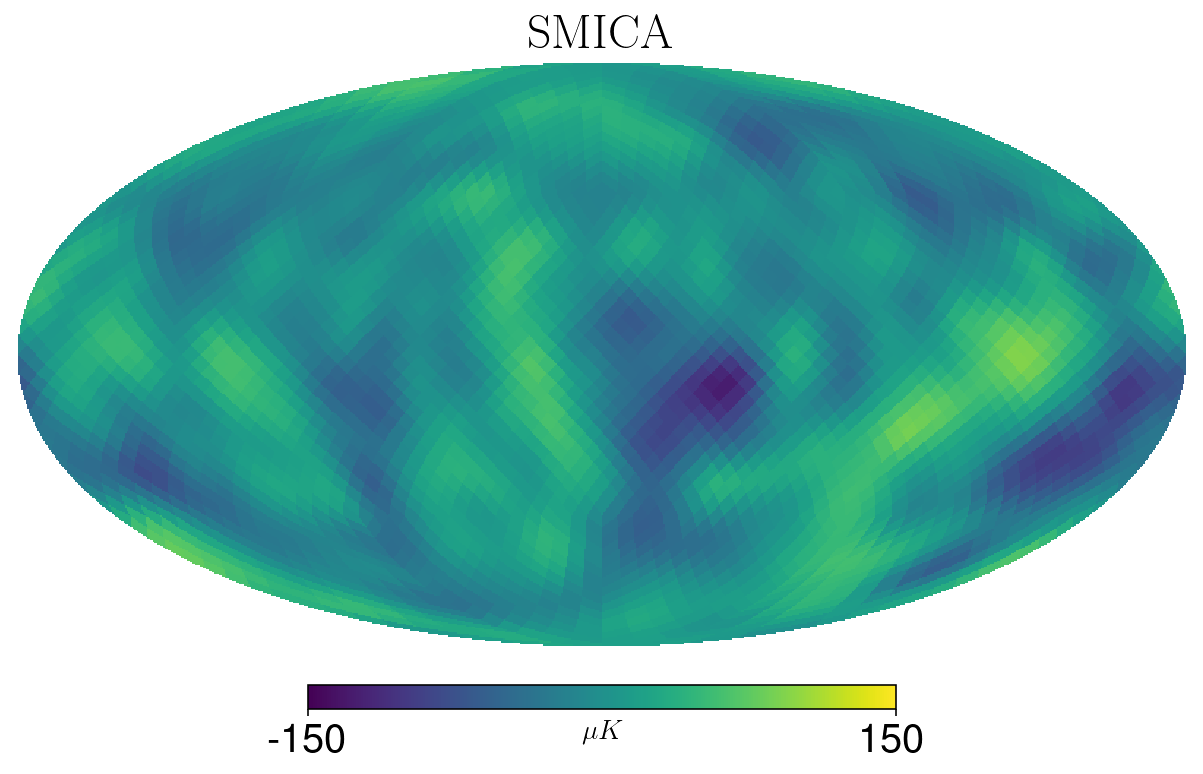

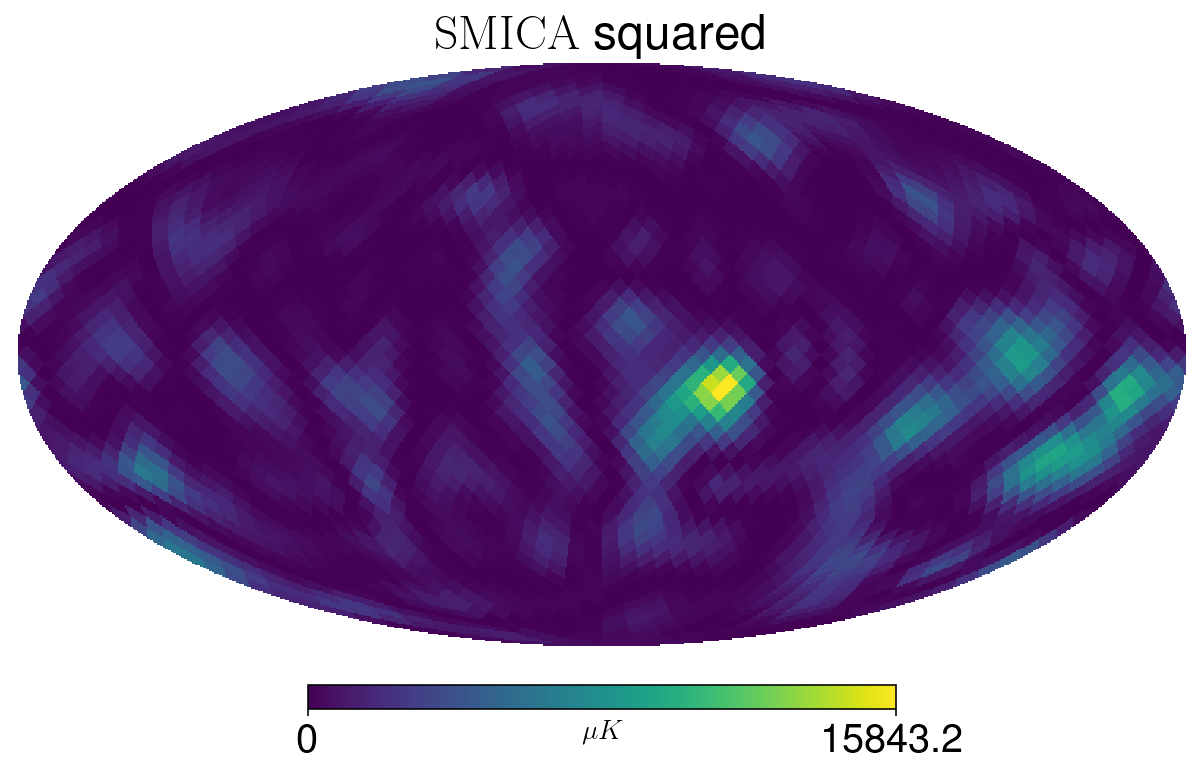

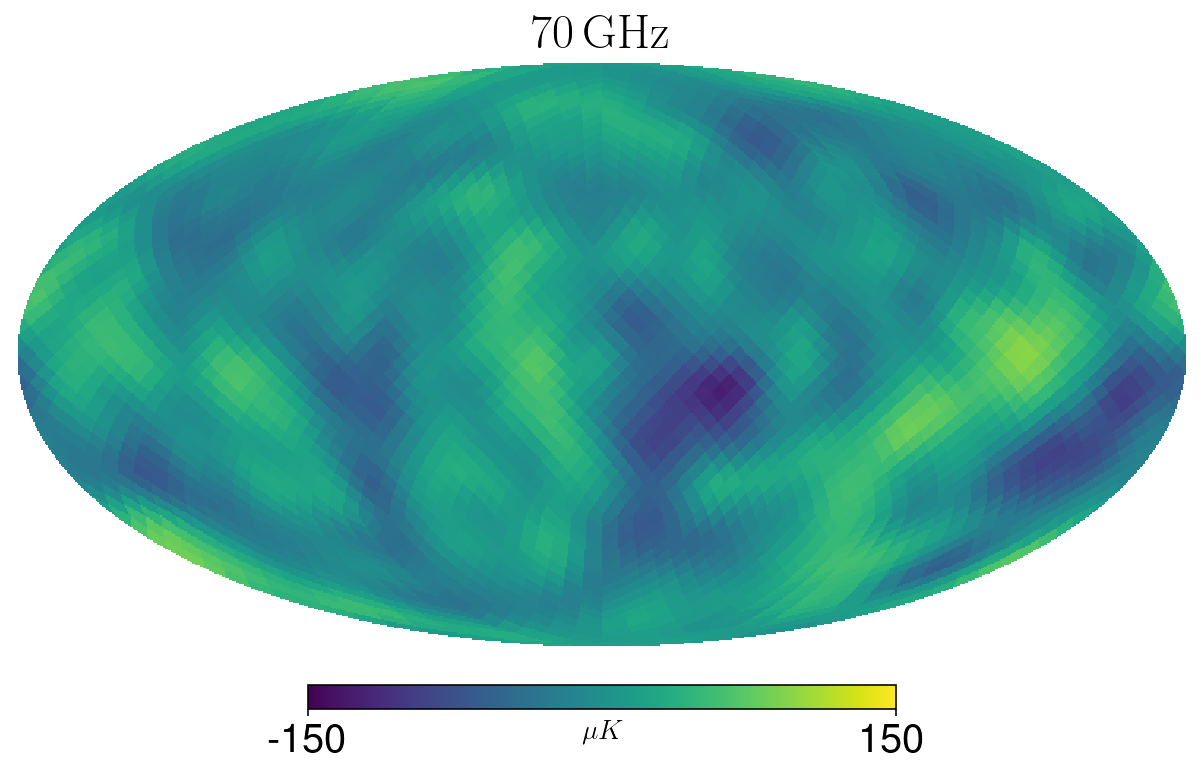

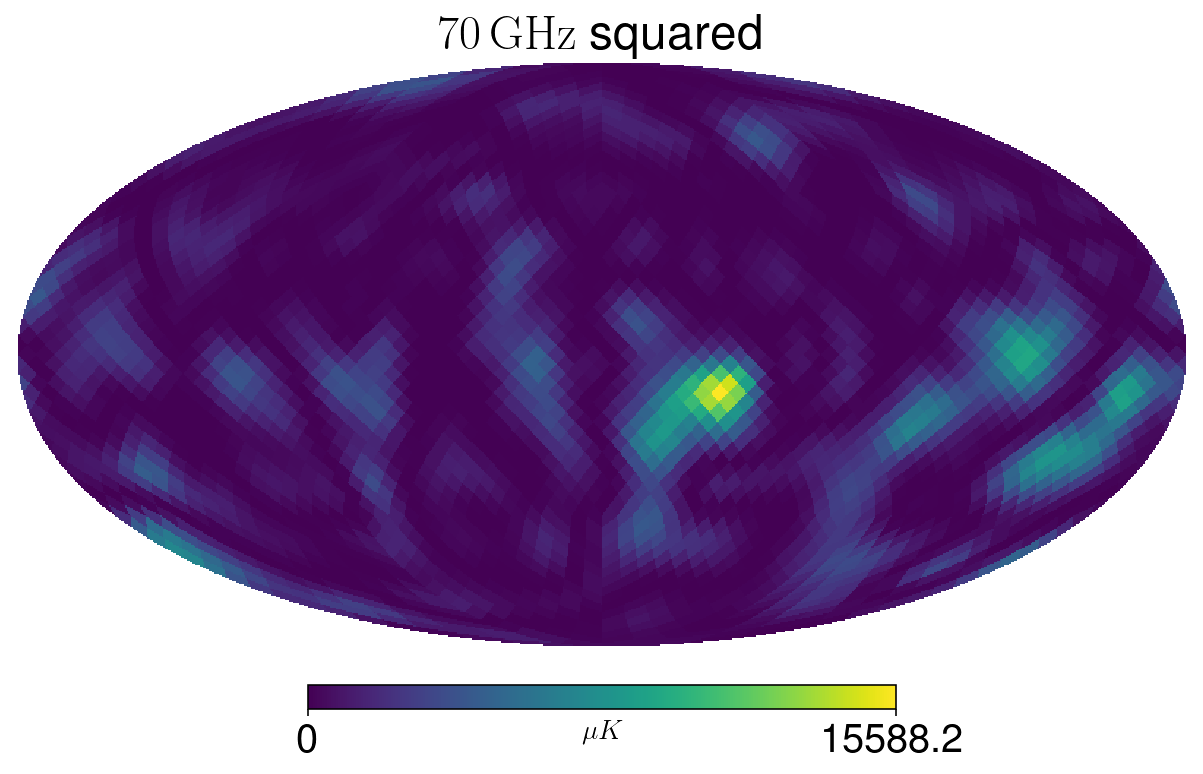

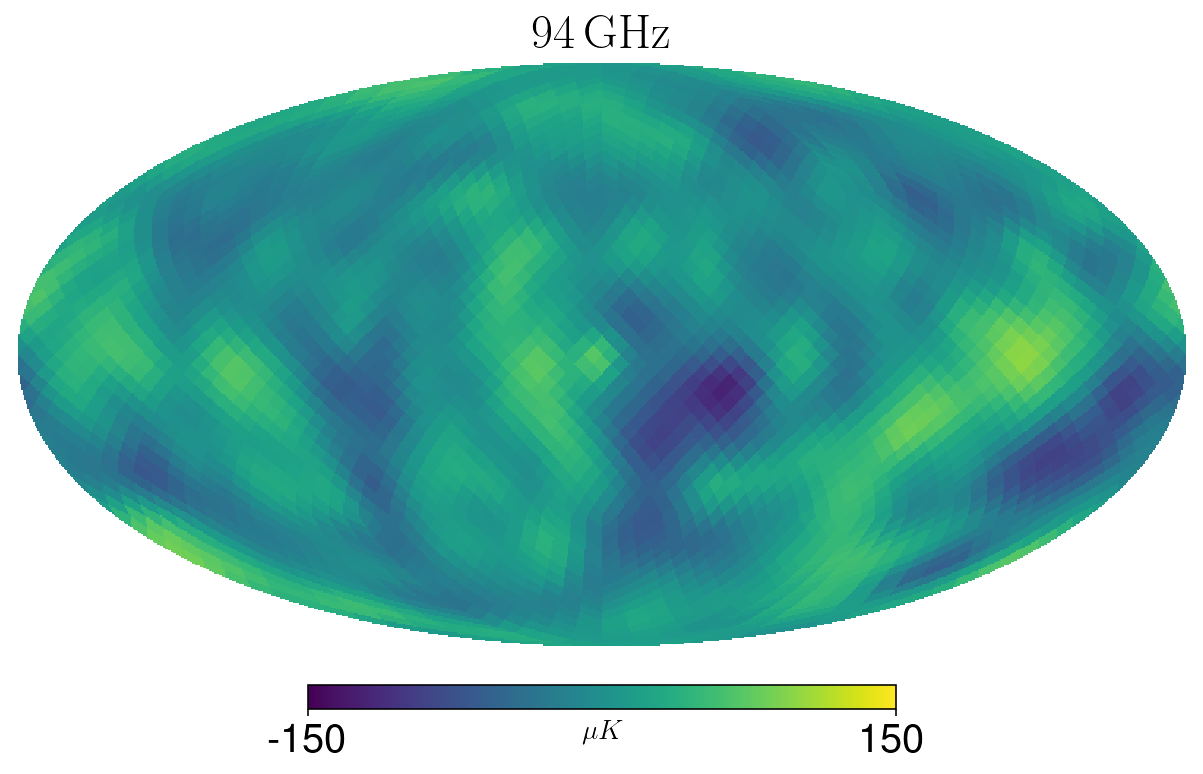

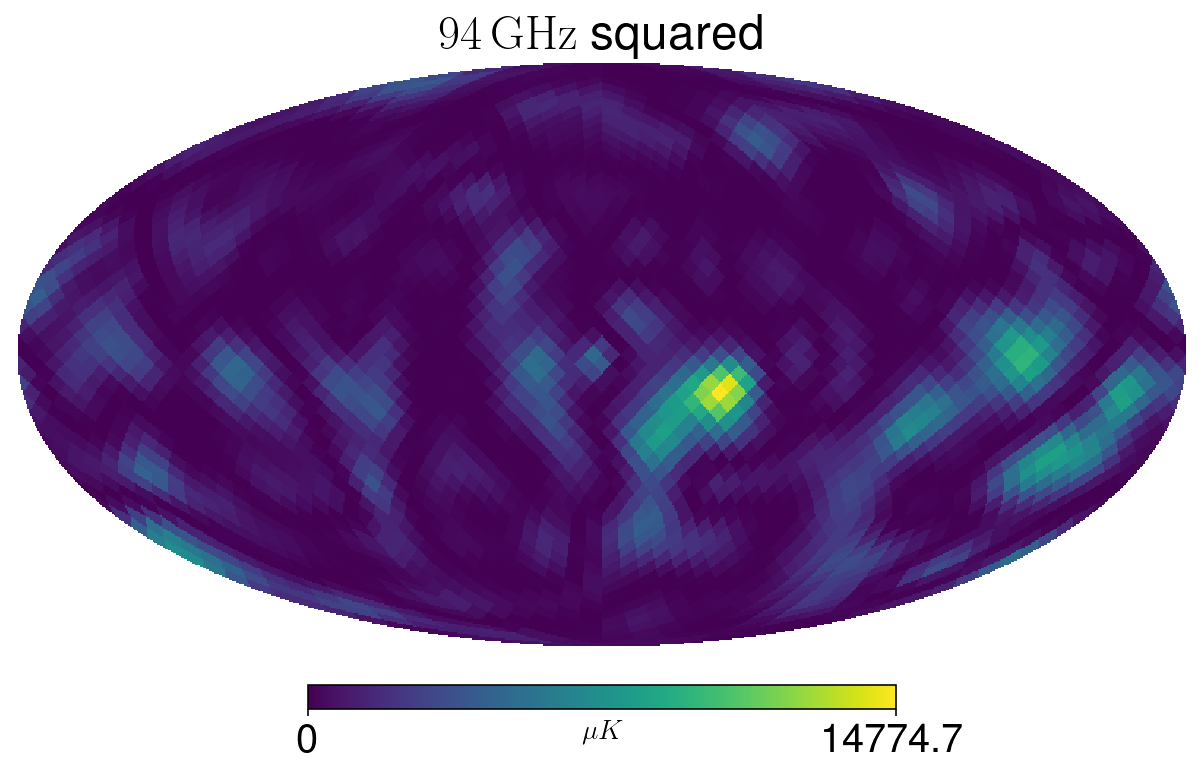

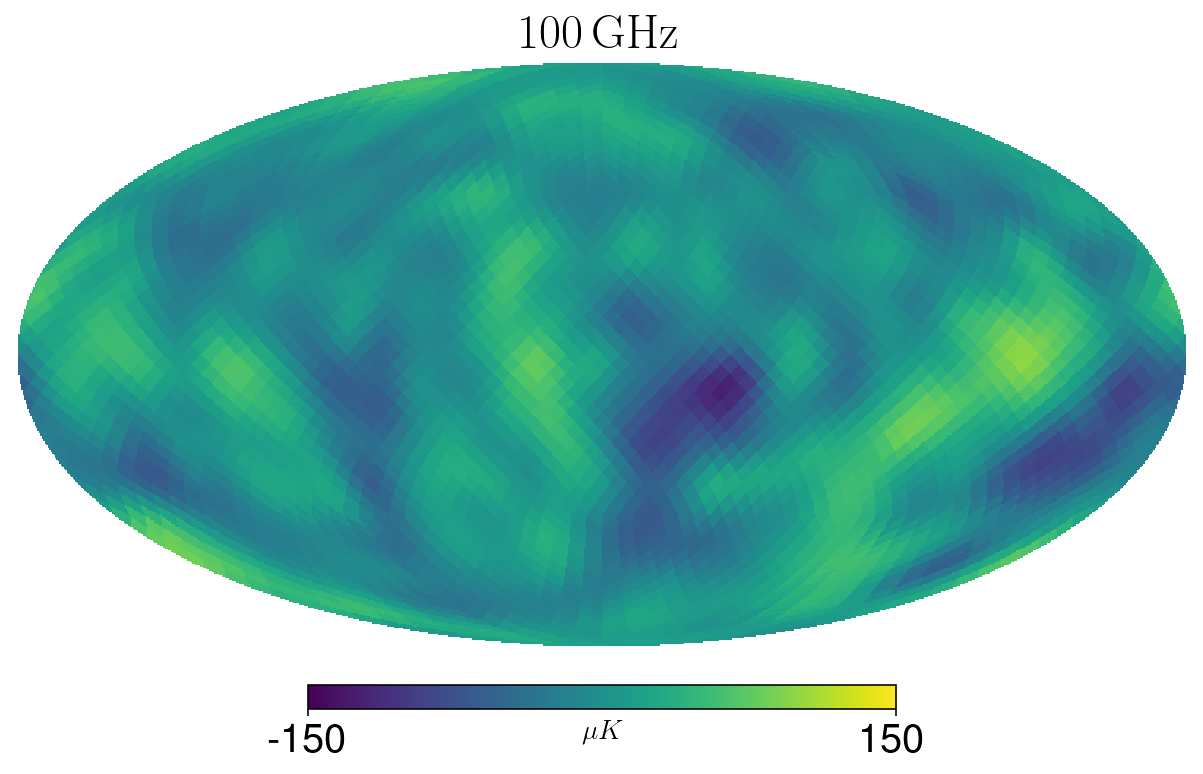

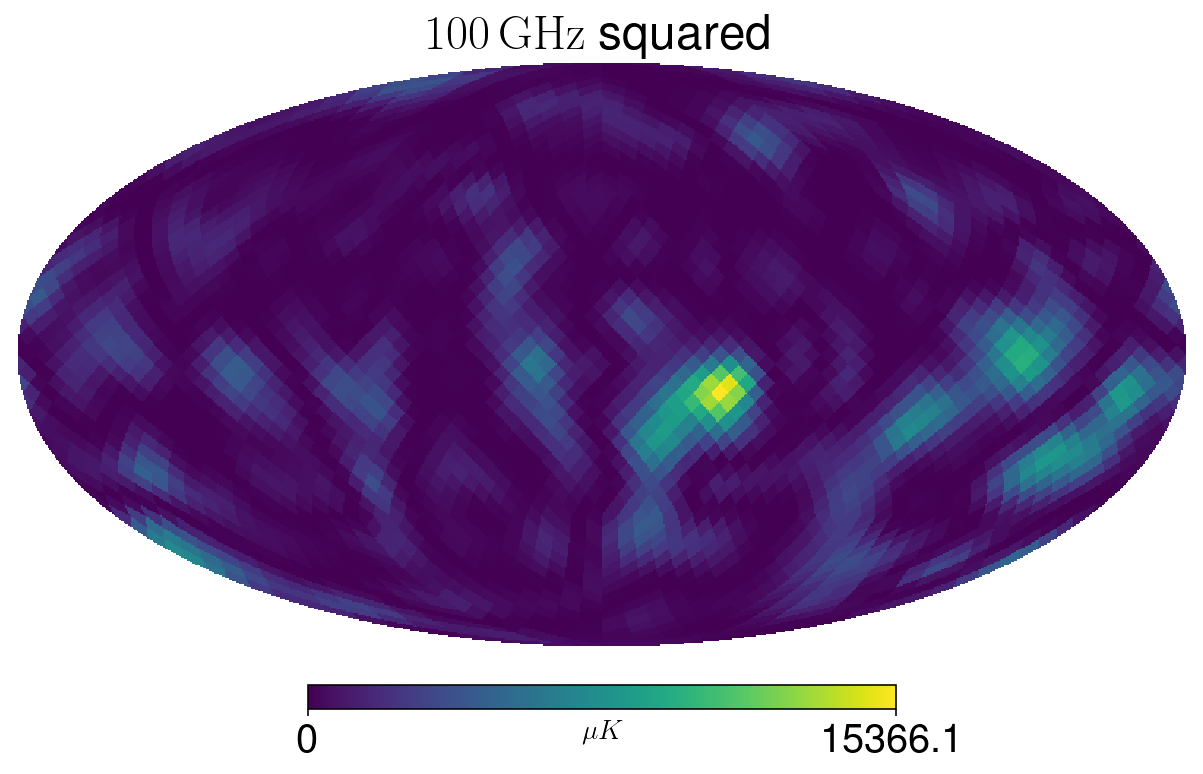

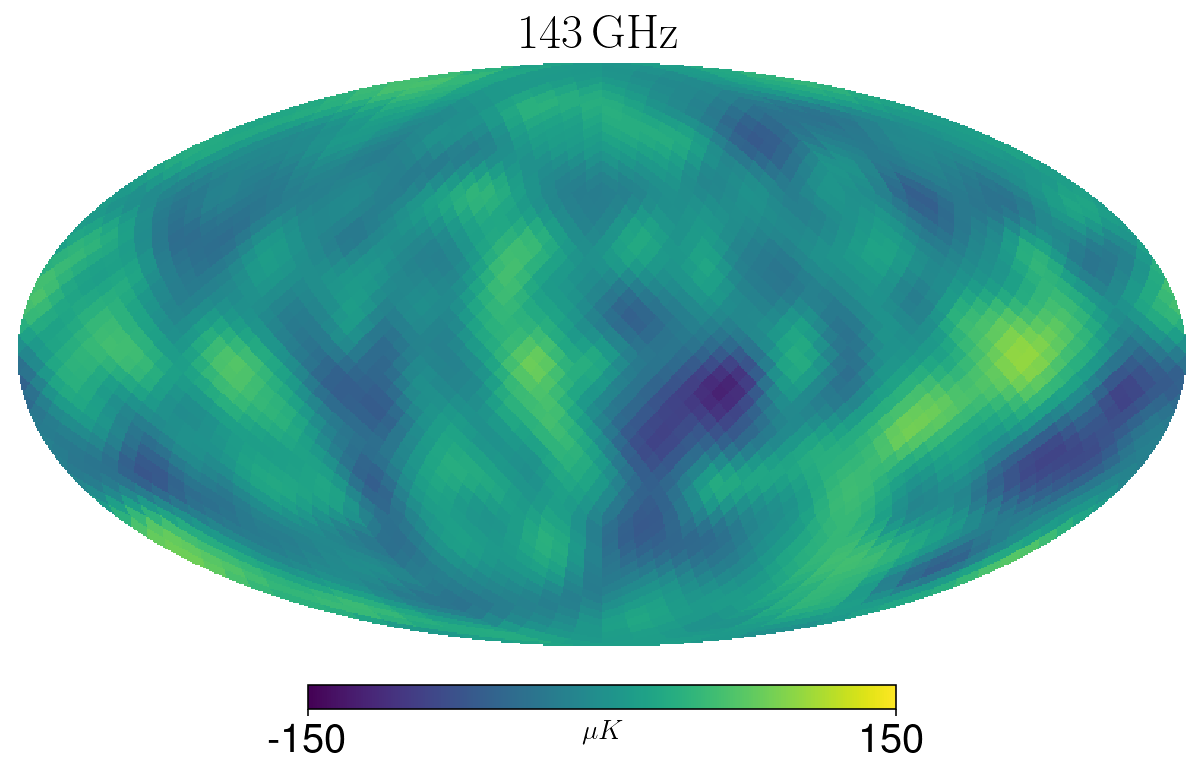

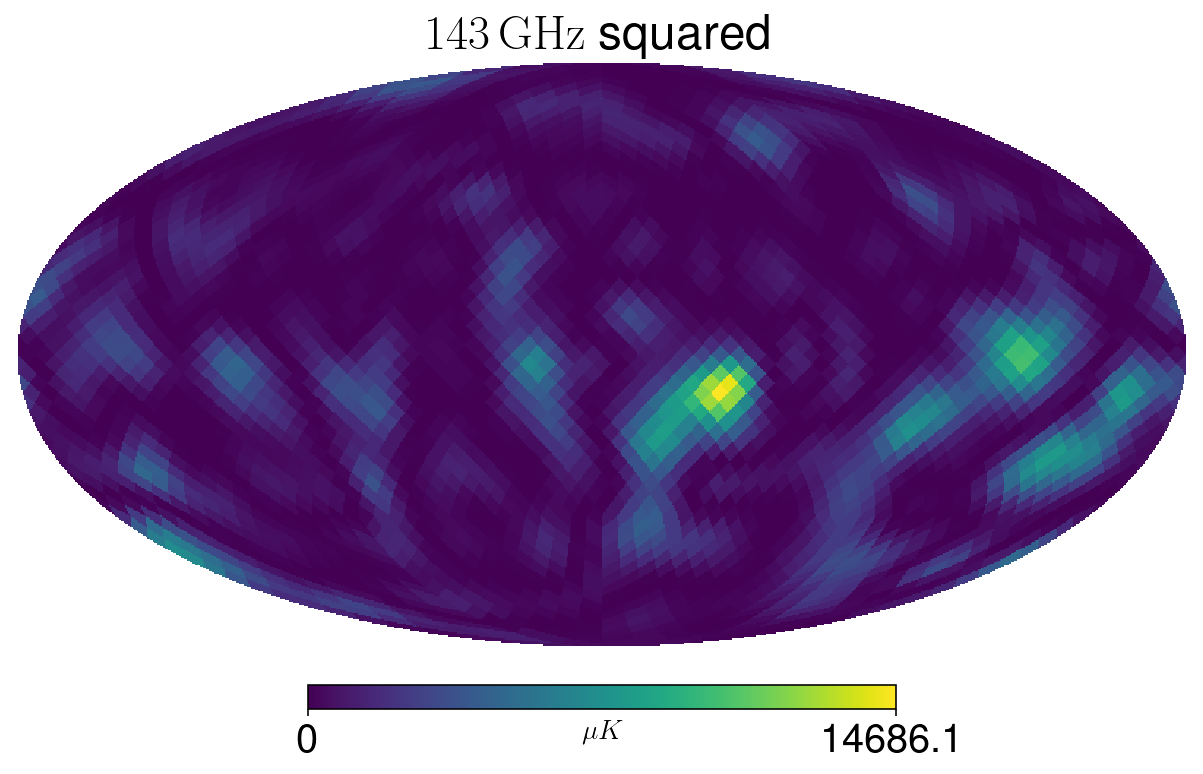

In [7]:
# Plot maps
m=0
for n in range(Nmaps): 
    hp.mollview(maps_Planck[n], min=-150, max=150, unit=r"$\mu K$", title=labels_Planck[n])
    hp.mollview(maps_Planck[n]**2, min=0, unit=r"$\mu K$", title=labels_Planck[n]+" squared")

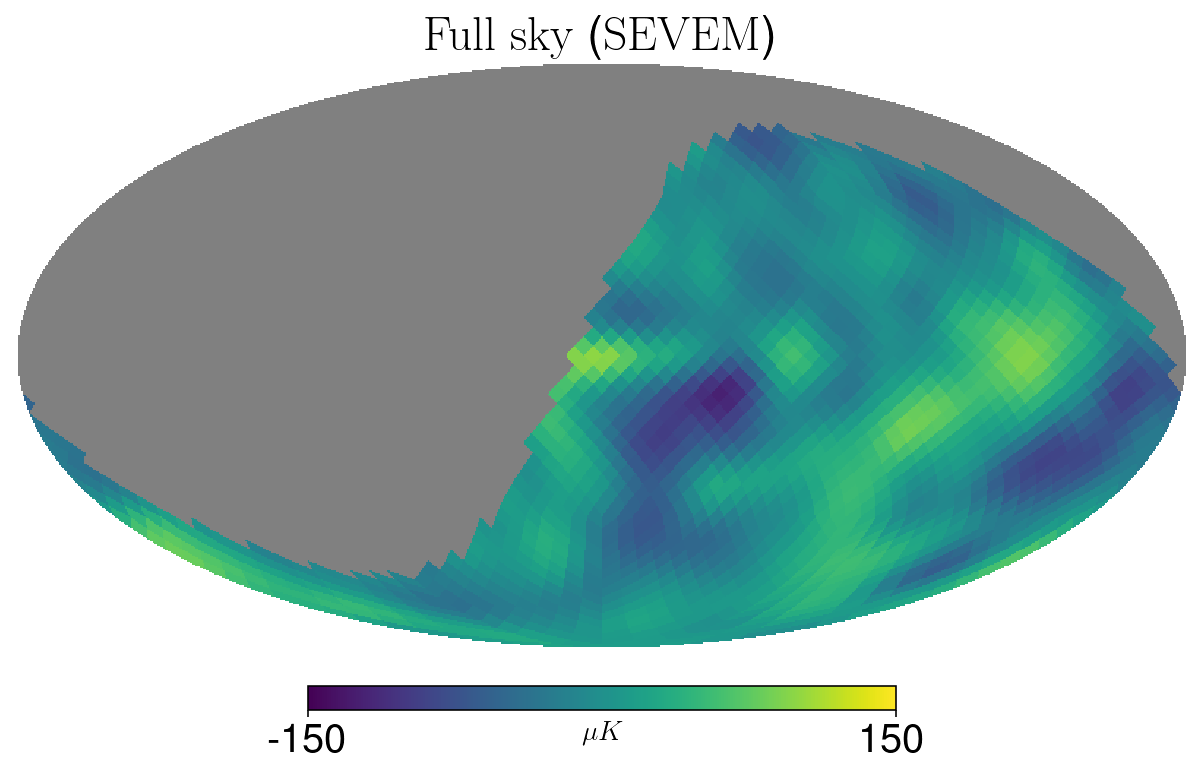

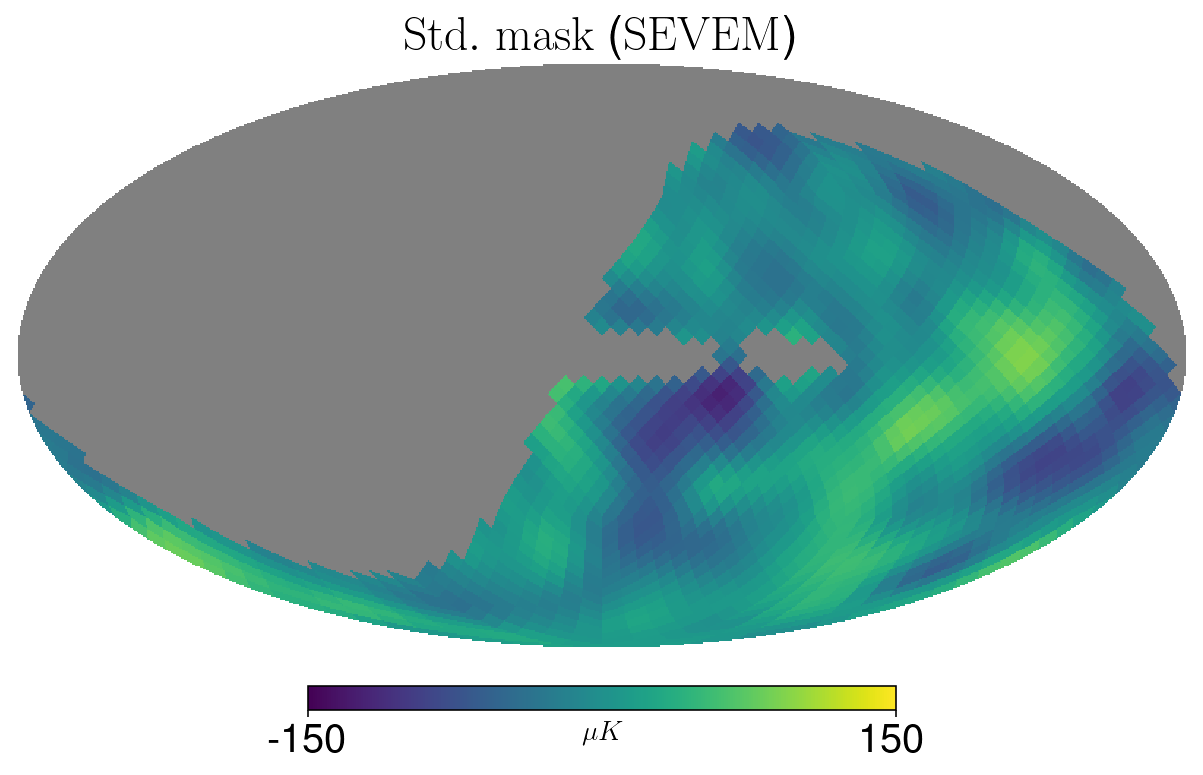

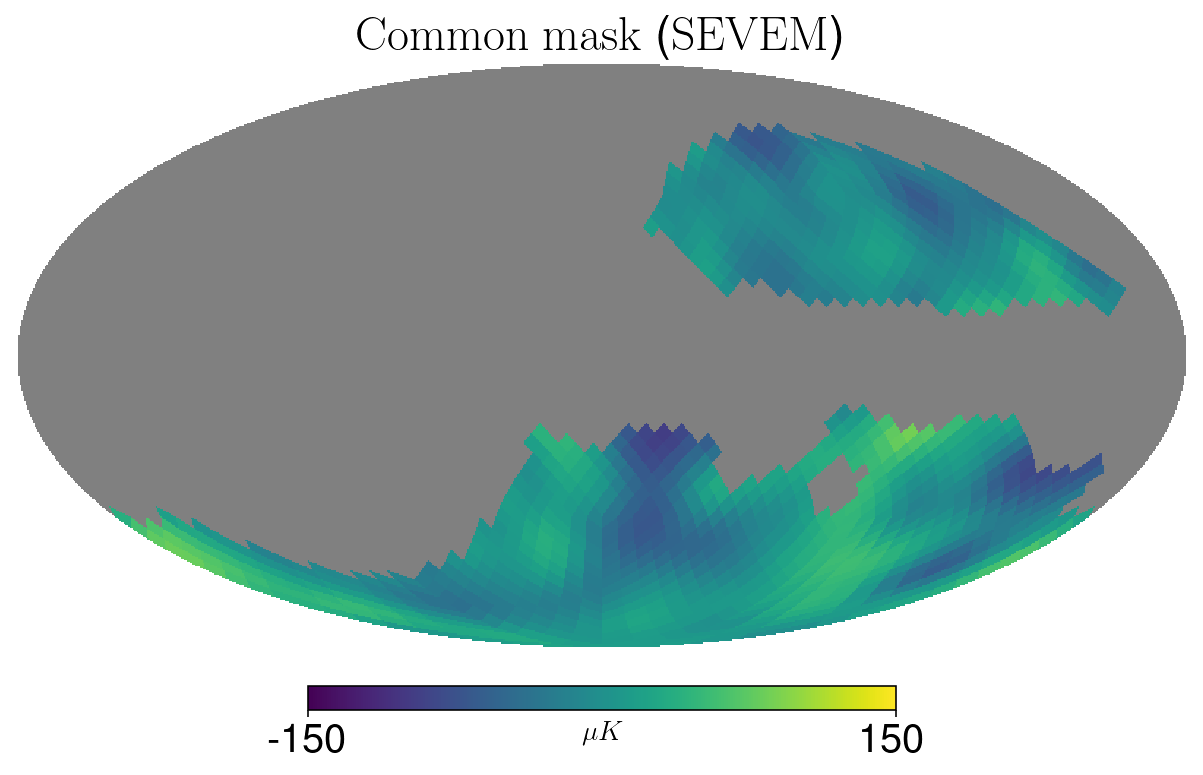

In [8]:
# Plot masks
n = 2
for m in range(Nmasks): hp.mollview(maps_Planck[n]*masks[m], min=-150, max=150, unit=r"$\mu K$", title=f"{labels_mask[m]} ({labels_Planck[n]})")

In [9]:
# Print sky fractions
print("Sky fractions:")
for m in range(Nmasks):
    print(f"{names_mask[m]}: {100*len(masks[m][~np.isnan(masks[m])])/len(masks[m]):.1f} %")

Sky fractions:
fullsky: 50.8 %
stdmask: 49.0 %
commask: 32.7 %


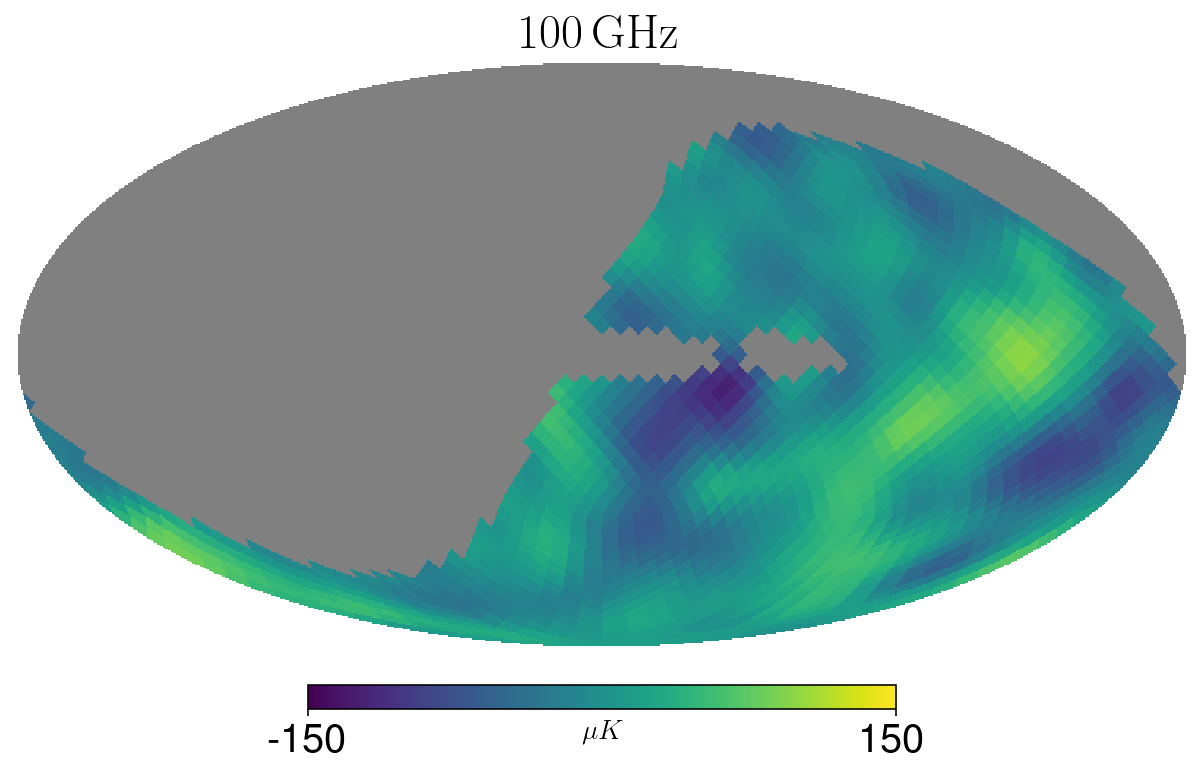

In [10]:
# Save 100 GHz for paper
hp.mollview(maps_Planck[index_Hayley]*masks[1], min=-150, max=150, unit=r"$\mu K$", title=labels_Planck[index_Hayley])
#plt.tight_layout()
plt.savefig("map_nside16_100GHz.pdf", format="PDF", bbox_inches='tight')

# Variance real maps

In [11]:
vars_Planck = np.array([[CMBanom.sigma2_16(maps_Planck[n],masks[m]) for n in range(Nmaps)] for m in range(Nmasks)])

In [12]:
vars_np  = np.array([[np.nanvar(maps_Planck[n]*masks[m]) for n in range(Nmaps)] for m in range(Nmasks)])
vars_fs = np.array([[np.nansum((maps_Planck[n]*masks[m]-np.nanmean(maps_Planck[n]*np.where(masks_01[m]==1., 1., np.nan)))**2)/len(np.nonzero(masks[m]==1.)[0]) for n in range(Nmaps)] for m in range(Nmasks)])
vars_zm = np.array([[np.nansum((maps_Planck[n]*masks[m])**2)/len(np.nonzero(masks[m]==1.)[0]) for n in range(Nmaps)] for m in range(Nmasks)])
                     
vars_Planck = vars_fs

In [13]:
print(vars_np)
print(vars_fs)
print(vars_zm)
print(len(np.nonzero(masks[m])[0]))
#print(np.nansum((maps_Planck[n]*masks[m]-np.nanmean(maps_Planck[n]*masks[m]))**2))

[[1453.30025378 1522.55184826 1457.96385826 1499.63469093 1472.56875835
  1460.95805567 1470.10719067 1458.06930897]
 [1470.99847448 1513.16600342 1422.41471121 1496.14935114 1478.61646808
  1459.12563004 1480.30360154 1470.20129462]
 [ 991.83157261 1031.3687926  1014.00295839  989.71856002 1004.22476385
  1007.25512456 1013.16511797 1004.97998248]]
[[1462.79799716 1536.62889508 1462.23816753 1505.44837121 1479.38686467
  1466.74080239 1476.45835197 1463.90943168]
 [1477.23032066 1522.74642889 1425.96108259 1499.20812445 1482.26887521
  1462.92280766 1484.01961948 1473.74105601]
 [ 991.83158432 1031.39215975 1014.01818064  990.24280822 1004.26491342
  1007.27531126 1013.20041761 1005.0056061 ]]
[[1460.27878981 1538.22703744 1462.25817897 1505.47231822 1474.98455707
  1461.48013462 1471.63398503 1458.92628213]
 [1475.23925412 1522.68308637 1433.33715796 1498.49924555 1479.44451988
  1459.40044012 1480.849554   1470.47059789]
 [ 996.21614982 1031.42538416 1017.27770658  992.32165416 1006

# Variance sims
Generate maps, compute variance on northern hemisphere on the fly without saving the map

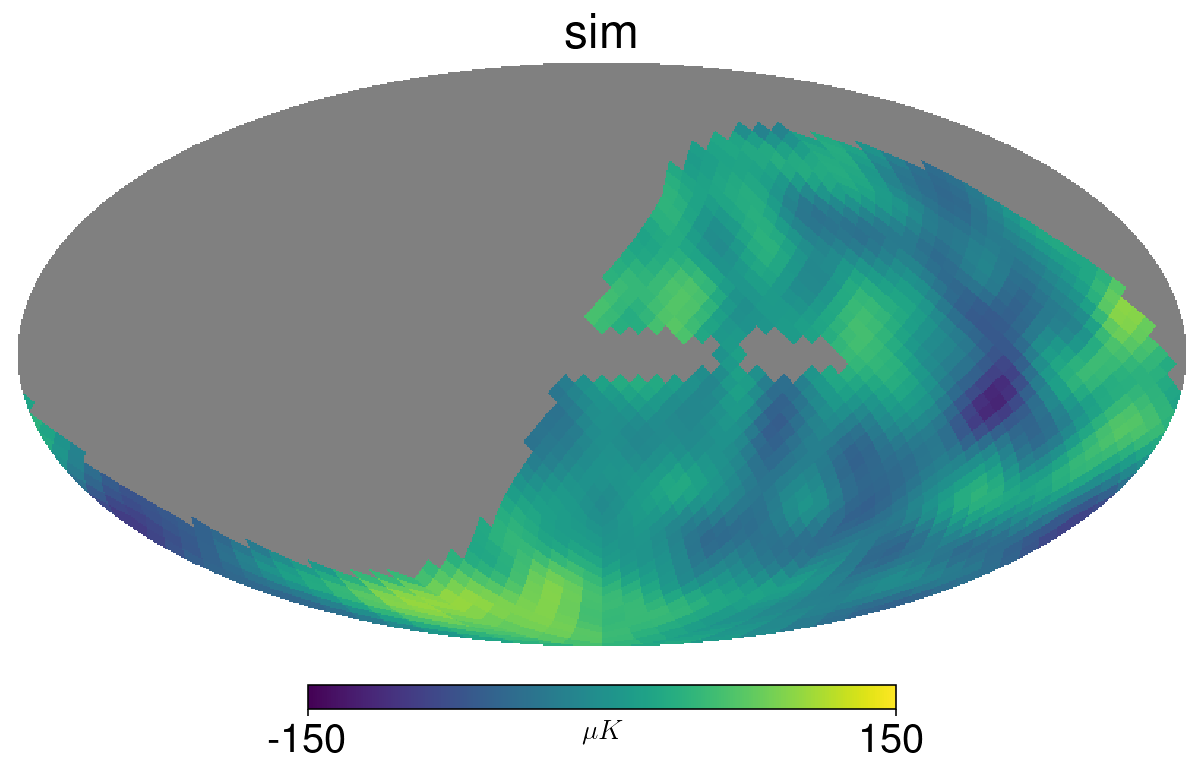

In [14]:
if load_stats_from_cluster:
    vars_sims = [np.loadtxt(stats_dir+f"sigma16_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
else:
    if gen_maps_on_fly:
        NSIDEtoFWHMarcmin = {2048:5, 1024:10, 512:20, 256:40, 128:80, 64:160, 32:320, 16:640}
        lmax=200
        data = np.loadtxt(cl_fn, skiprows=1)
        llist = np.arange(lmax+1)
        Clist = np.zeros(lmax+1)
        Clist[2:] = data[:lmax-1, 1]*2.*np.pi/(llist[2:]*(llist[2:] + 1))

        # Generate maps and save var
        vars_sims = [[],[],[]]
        seeds = np.arange(0,Nsims)
        for seed in seeds:
            np.random.seed(seed)
            m_128 = hp.sphtfunc.synfast(Clist, nside=128, fwhm=CMBanom.arcmin2rad(NSIDEtoFWHMarcmin[128]), pixwin=True)  
            m = CMBanom.downgrade_map(m_128, Nside_out)
            vars_sims[0].append(CMBanom.sigma_16(m, mask_for_north))
            vars_sims[1].append(CMBanom.sigma_16(m, mask_for_north*mask_std))
            vars_sims[2].append(CMBanom.sigma_16(m, mask_for_north*mask_com))
        
    else:
        maps_128  = [hp.read_map(sims_dir+f"map__{n}.fits") for n in range(Nsims)]
        maps_16   = [CMBanom.downgrade_map(map, Nside_out) for map in maps_128]
        vars_sims = [[CMBanom.sigma2_16(map, mask) for map in maps_16] for mask in masks]
        #vars_sims = np.array([[np.nansum((maps_16[n]*masks[m]-np.nanmean(maps_16[n]*np.where(masks_01[m]==1., 1., np.nan)))**2)/len(np.nonzero(masks[m]==1.)[0]) for n in range(Nsims)] for m in range(Nmasks)])
    hp.mollview(maps_16[12]*masks[1], title="sim", unit=r"$\mu K$", min=-150, max=150)
mean_vars_sims = np.mean(np.array(vars_sims),axis=1)

# Compare northern & southern hemisphere

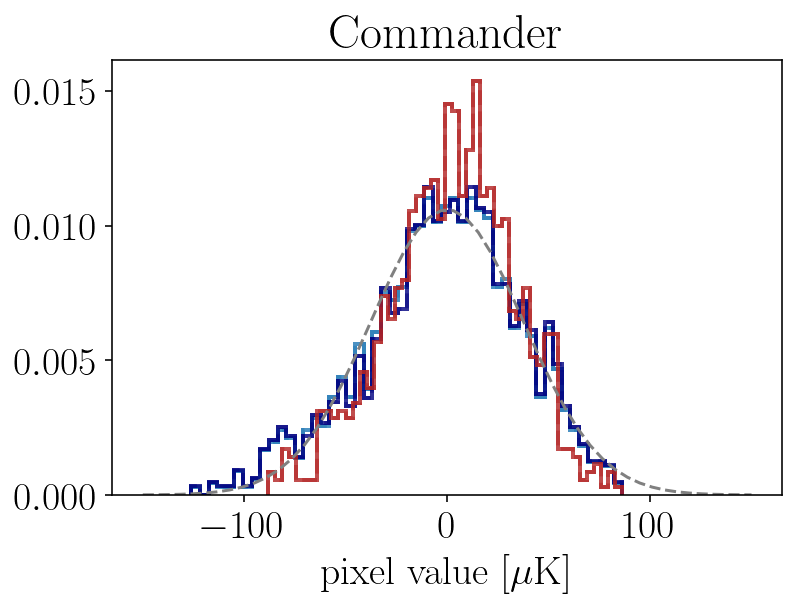

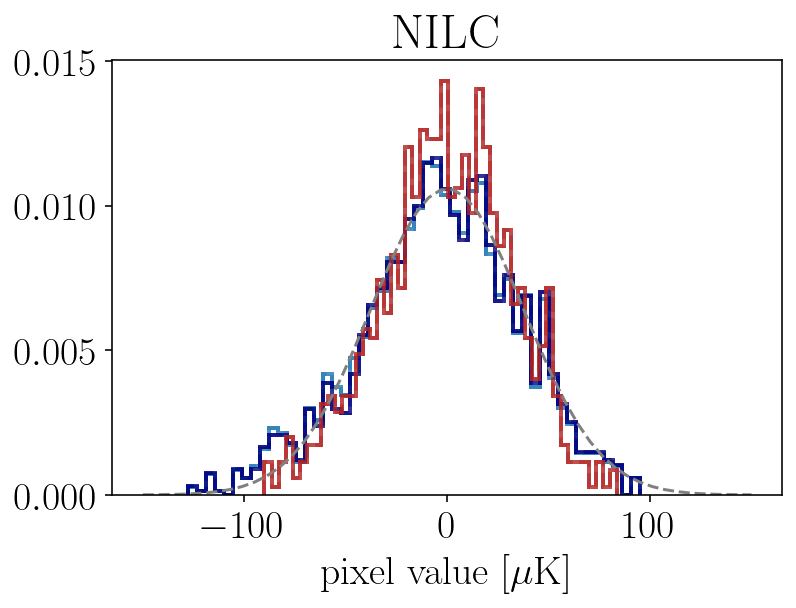

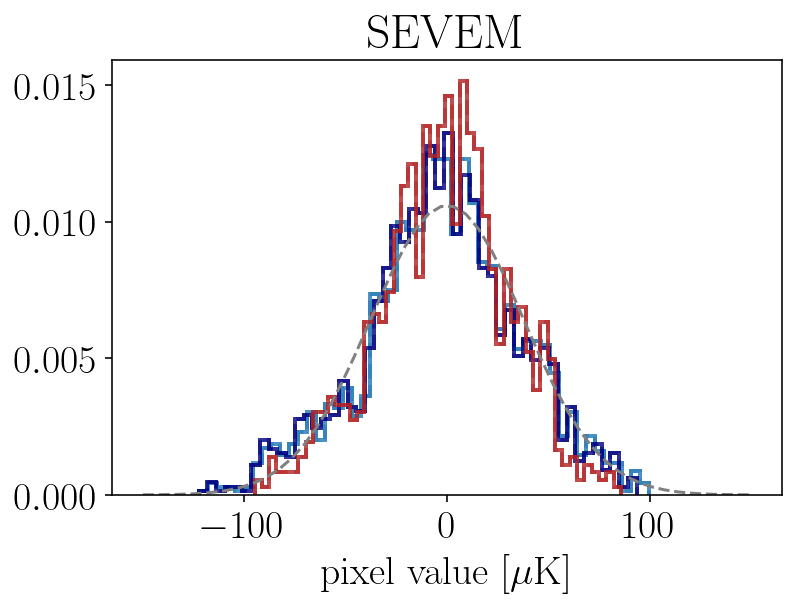

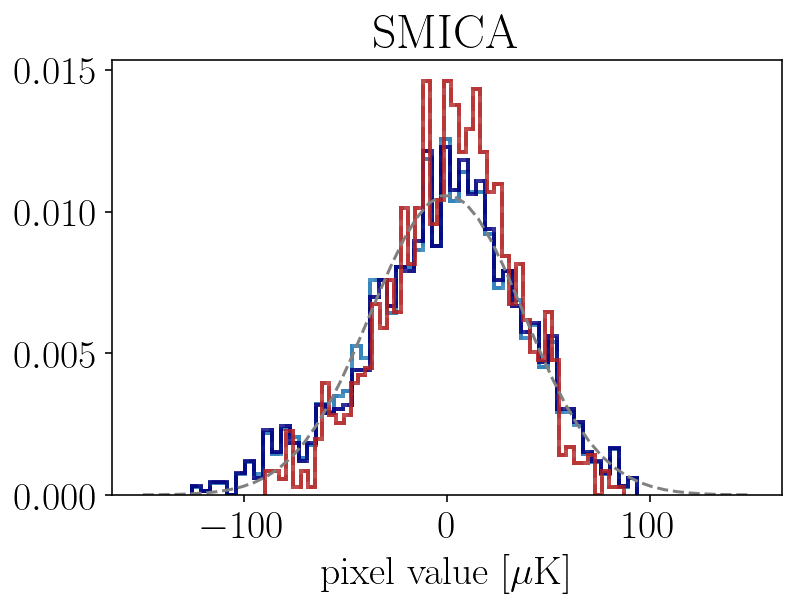

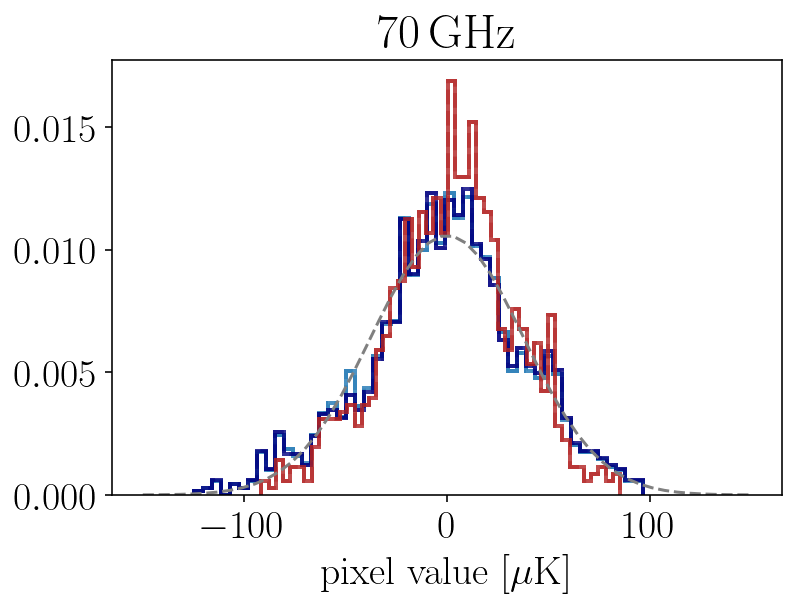

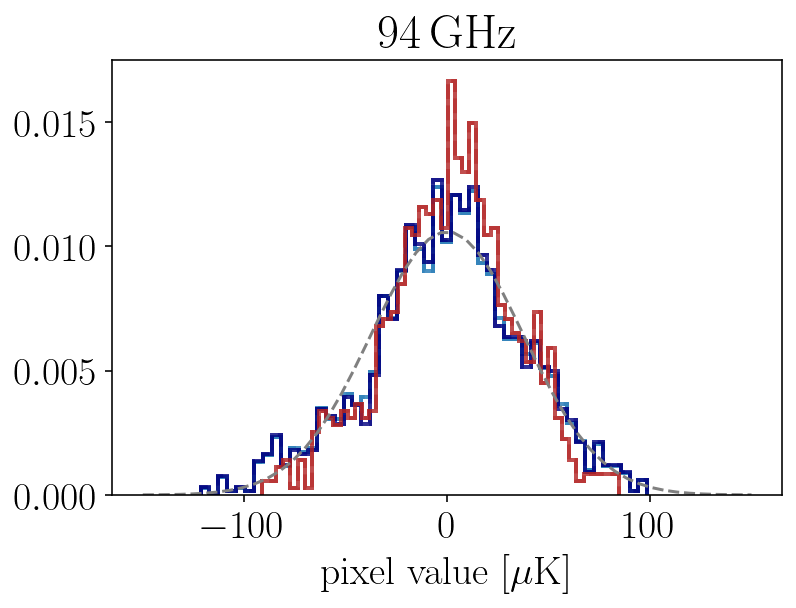

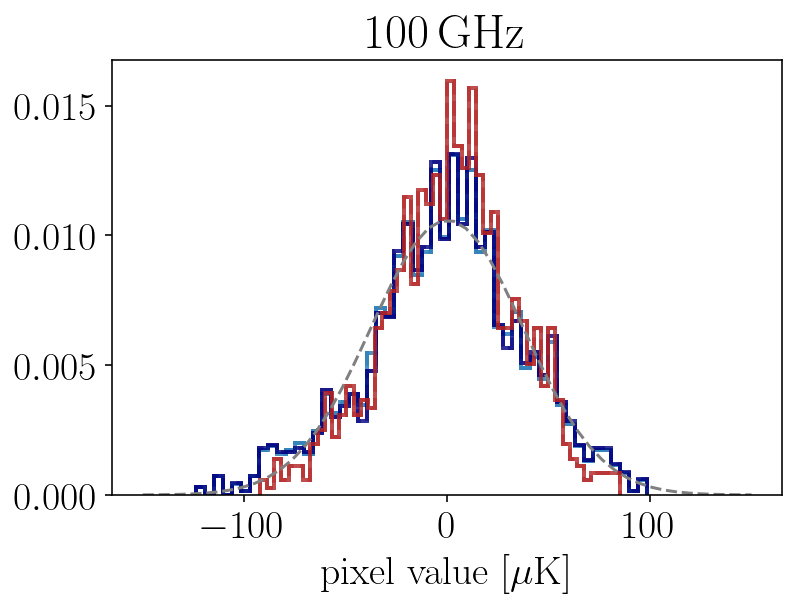

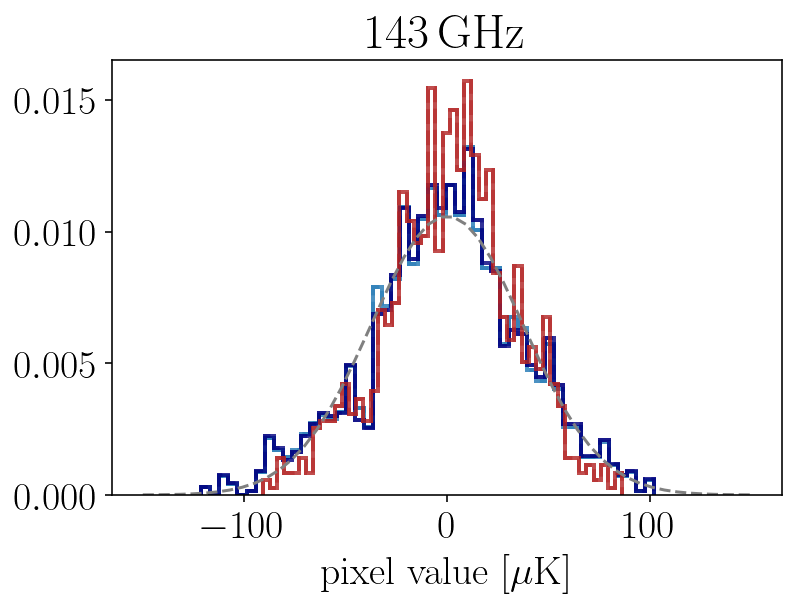

In [15]:
for n in range(Nmaps):
    plt.plot([0], [0], color='grey', alpha=0.8, ls="-",  lw=3, label=r'$\mathrm{Northern\ hemisphere}$')
    plt.plot([0], [0], color='grey', alpha=0.5, ls="--", lw=3, label=r'$\mathrm{Southern\ hemisphere}$')
    for m in range(Nmasks):
        h=plt.hist(maps_Planck[n]*masks[m], bins=50, alpha=0.8, label=labels_mask[m], histtype="step", lw=2, color=colors_mask[m], density=True)
        h=plt.hist(maps_Planck[n]*masks_south[m], bins=50, alpha=0.5, histtype="step", lw=2, color=colors_mask[m], density=True, ls="--")
    plt.plot(np.linspace(-150,150, 50), norm.pdf(np.linspace(-150,150, 50), 0, np.sqrt(mean_vars_sims[0])), color="grey", ls="--")

    plt.title(labels_Planck[n])
    plt.xlabel(r"$\mathrm{pixel\ value\ [}\mu \mathrm{K]}$")
    #plt.legend(loc="upper left", prop=prop)
    plt.show()

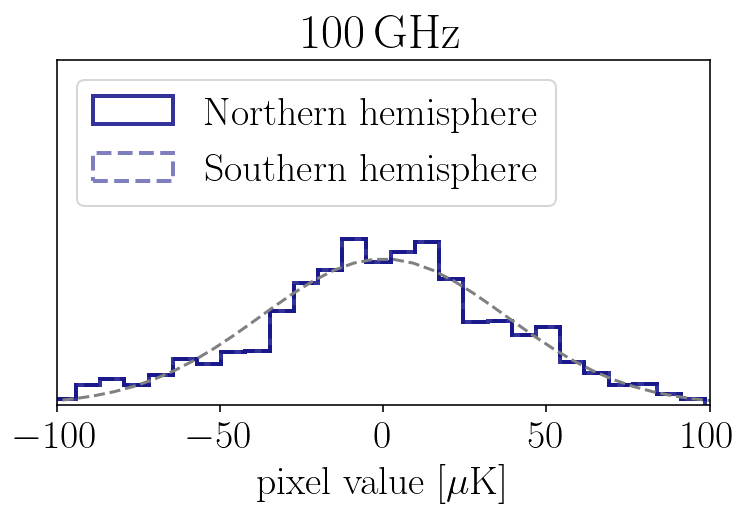

In [16]:
m=1
h=plt.hist(maps_Planck[index_Hayley]*masks[m], bins=30, alpha=0.8, histtype="step", lw=2, color=colors_mask[m], density=True, label=r'$\mathrm{Northern\ hemisphere}$')
h=plt.hist(maps_Planck[index_Hayley]*masks_south[m], bins=30, alpha=0.5, histtype="step", lw=2, color=colors_mask[m], density=True, ls="--", label=r'$\mathrm{Southern\ hemisphere}$')
plt.plot(np.linspace(-150,150, 50), norm.pdf(np.linspace(-150,150, 50), 0, np.sqrt(mean_vars_sims[0])), color="grey", ls="--")

plt.title(labels_Planck[index_Hayley])
plt.xlabel(r"$\mathrm{pixel\ value\ [}\mu \mathrm{K]}$")
plt.legend(loc="upper left", prop=prop)
plt.xlim(-100, 100)
plt.ylim(0, 0.025)
plt.tight_layout()
plt.yticks([])
plt.savefig("pixel_histogram_100GHz.pdf", format="PDF")
plt.show()

# Results plots

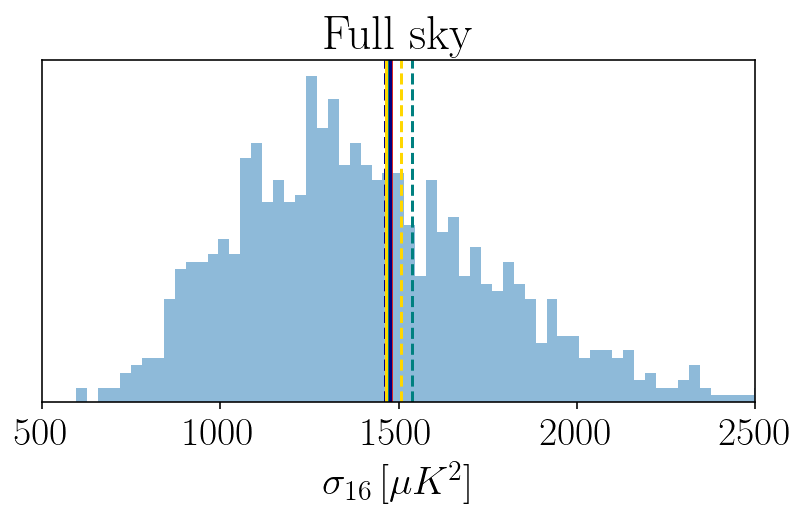

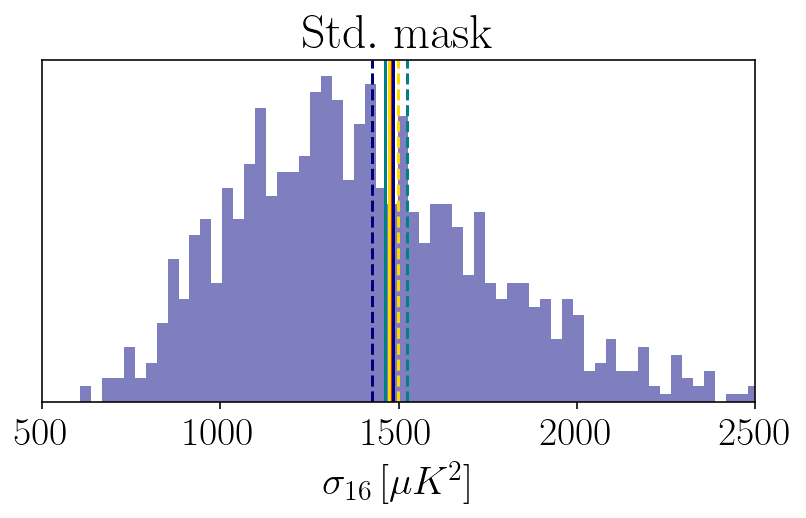

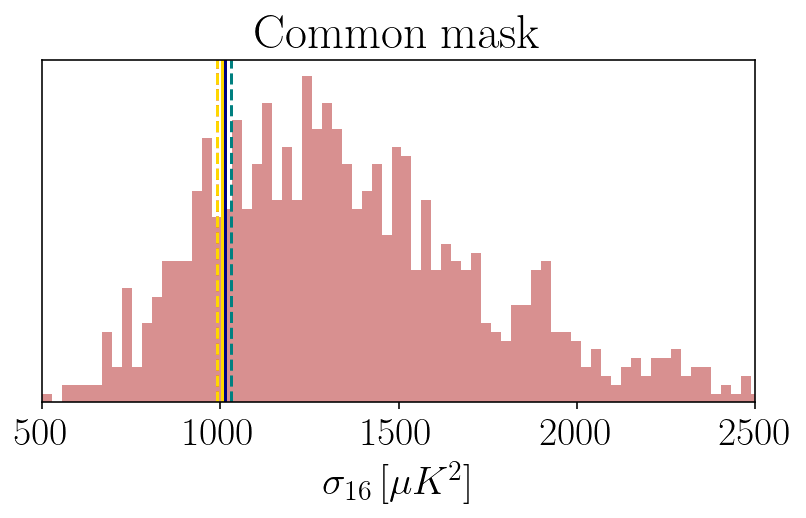

In [17]:
for m in range(Nmasks):
    plt.title(labels_mask[m])
    h=plt.hist(vars_sims[m], bins=100, alpha=0.5, color=colors_mask[m])
    for n in range(Nmaps): plt.axvline(vars_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    plt.xlim(500, 2500)
    plt.xlabel(r"$\sigma_{16}\, [\mu K^2]$")
    #plt.legend(loc="lower right")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    plt.tight_layout()
    plt.savefig("hist_sigma16_"+names_mask[m]+".pdf", format="PDF")
    plt.show()


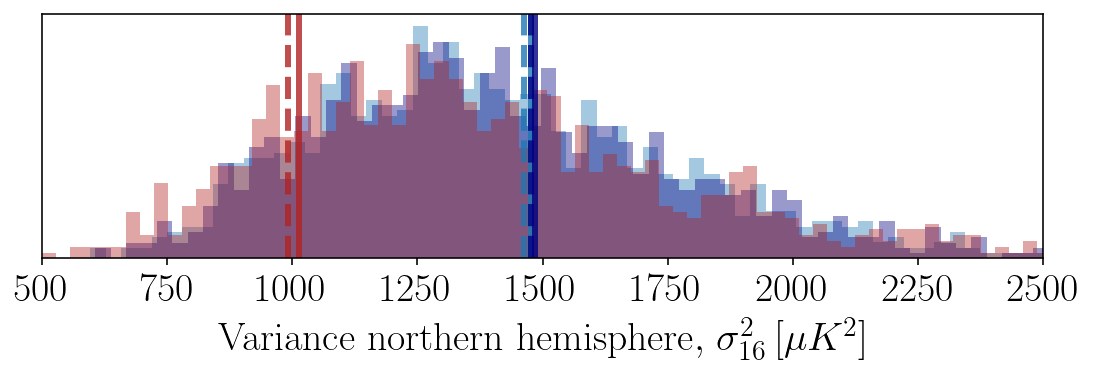

In [18]:
fig = plt.figure(figsize=(8, 3))
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(vars_sims[m], bins=100, alpha=0.4, density=True, color=colors_mask[m])
    plt.axvline(vars_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    plt.axvline(vars_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
plt.xlim(500, 2500)
plt.xlabel(r"$\mathrm{Variance\ northern\ hemisphere,}\ \sigma^2_{16}\, [\mu K^2]$")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
#plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_sigma16.pdf", format="PDF")
plt.show()

## Compute p-values

In [19]:
pvals = [[CMBanom.pval_lower(vars_Planck[m][n], vars_sims[m]) for n in range(Nmaps)] for m in range(Nmasks)]

In [20]:
for m in range(Nmasks):
    print("-----------")
    print(names_mask[m])
    for n in range(Nmaps):
        print(f"sigma_16 = {vars_Planck[m][n]:.2f}, p-value: {100*pvals[m][n]:.2f}% ({names_Planck[n]})")
    #print(f"sigma_16 = {vars_Planck_std_mask[n]:.2f}, p-value: {100*pvals_std_mask[n]:.2f}% ({labels_Planck[n]})")

-----------
fullsky
sigma_16 = 1462.80, p-value: 59.80% (commander_nside_128)
sigma_16 = 1536.63, p-value: 67.00% (nilc_nside_128)
sigma_16 = 1462.24, p-value: 59.70% (sevem_nside_128)
sigma_16 = 1505.45, p-value: 64.10% (smica_nside_128)
sigma_16 = 1479.39, p-value: 61.70% (cleaned70GHz_v7_nside_128)
sigma_16 = 1466.74, p-value: 60.40% (cleaned94GHz_v7_nside_128)
sigma_16 = 1476.46, p-value: 61.40% (cleaned100GHz_v7_nside_128)
sigma_16 = 1463.91, p-value: 60.20% (cleaned143GHz_v7_nside_128)
-----------
stdmask
sigma_16 = 1477.23, p-value: 61.30% (commander_nside_128)
sigma_16 = 1522.75, p-value: 65.90% (nilc_nside_128)
sigma_16 = 1425.96, p-value: 56.80% (sevem_nside_128)
sigma_16 = 1499.21, p-value: 63.20% (smica_nside_128)
sigma_16 = 1482.27, p-value: 61.70% (cleaned70GHz_v7_nside_128)
sigma_16 = 1462.92, p-value: 60.20% (cleaned94GHz_v7_nside_128)
sigma_16 = 1484.02, p-value: 61.90% (cleaned100GHz_v7_nside_128)
sigma_16 = 1473.74, p-value: 61.20% (cleaned143GHz_v7_nside_128)
------

### Compare to Jones++ 2023 (common mask)
$\sigma_{16} = 617.6,\ \text{p-value:}\ 0.31\%$ (Commander)

$\sigma_{16} = 605.9,\ \text{p-value:}\ 0.25\%$ (NILC)

$\sigma_{16} = 583.4,\ \text{p-value:}\ 0.16\%$ (SEVEM)

$\sigma_{16} = 631.0,\ \text{p-value:}\ 0.39\%$ (SMICA)

In [21]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*pvals[m][n]:.2f} ", end="")
    print("\\\\")

p-values
fullsky : &59.80 &67.00 &59.70 &64.10 &61.70 &60.40 &61.40 &60.20 \\
stdmask : &61.30 &65.90 &56.80 &63.20 &61.70 &60.20 &61.90 &61.20 \\
commask : &16.90 &20.30 &18.60 &16.80 &18.20 &18.30 &18.60 &18.20 \\


In [22]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{vars_Planck[m][n]:.0f} ", end="")
    print("\\\\")

stats
fullsky : &1463 &1537 &1462 &1505 &1479 &1467 &1476 &1464 \\
stdmask : &1477 &1523 &1426 &1499 &1482 &1463 &1484 &1474 \\
commask : &992 &1031 &1014 &990 &1004 &1007 &1013 &1005 \\


In [23]:
for m in range(Nmasks):
    print(m)
    for n in range(Nmaps):
        print(np.nanmean(maps_16[n]*masks[m]))

0
-1.099677485924611
2.082663342306506
-3.198522233579235
-0.29652834521735677
-2.4934657676036056
0.7715791933767838
0.2891353625329479
0.1344766648450489
1
-1.6497243282742808
0.9812841164752041
-4.3694311935670225
0.27405693012432697
-3.775690285814632
1.6998330769866794
0.9062211782517315
0.893217267429562
2
-4.8013994626700285
-6.449644579953818
-14.78462784446193
0.8916677809593483
-7.40717189691481
14.111944686751833
3.040768258659489
1.520707836478617
